# Imports

In [10]:
import os
import keras
from PIL import Image
from keras import layers
import matplotlib.pyplot as plt

# Importering av data

In [11]:
if not os.path.exists("data/fashion_mnist_images/train") or not os.path.exists("data/fashion_mnist_images/test"):
    # raderar fel plaserad data eller gammal data
    
    if os.path.exists("data/fashion_mnist_images") and not os.path.exists("data/fashion_mnist_images/train") and not os.path.exists("data/fashion_mnist_images/test"): 
        print("starting to overwrite old data")
        for folder_name in os.listdir("data/fashion_mnist_images"):
            folder_path = os.path.join("data/fashion_mnist_images", folder_name)

            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path ,file_name)
                print(f"is file: {os.path.isfile(file_path)}, {file_path}")
                
                os.remove(file_path)  # Remove the file
                #print(f"removed file {file_path}")
        
        os.rmdir(folder_path)
        print(f"--removed folder {folder_path}")
                
    #  Ladda dataset
        (x_train, y_train),(x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Klassnamn (viktigt för mappar)
        class_names = [
            "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
        ]

        # Root folder
        base_path = "data/fashion_mnist_images"

        # Skapa mappar per klass för tränings data
        if not os.path.exists(f"{base_path}/train"):

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"train", class_name), exist_ok=True)

            # Spara träningsbilder
            for i, (img, label) in enumerate(zip(x_train, y_train)):

                class_name = class_names[label]
                
                path = os.path.join(base_path,"train", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else:
             print("Test data already importet")

        if not os.path.exists(f"{base_path}/test"):
            # Skapa mappar per klass på test data

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"test", class_name), exist_ok=True)

            # Spara testbilder
            for i, (img, label) in enumerate(zip(x_test, y_test)):

                class_name = class_names[label]

                path = os.path.join(base_path,"test", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else: 
             print("Train data already importet")

        print("Done with importing data")
else:
     print("Data already been imported")

Data already been imported


# Standard model

## Inläsning av data

In [12]:
train_dir = "data/fashion_mnist_images/train"
test_dir = "data/fashion_mnist_images/test"


IMG_SIZE = (28,28)
BATCH_SIZE = 128

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_data.class_names
normalization_layer = layers.Rescaling(1./255)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Första modelen

In [13]:
model_1 = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [14]:
history_1 = model_1.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8101 - loss: 0.5269 - val_accuracy: 0.8566 - val_loss: 0.3936
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8748 - loss: 0.3450 - val_accuracy: 0.8814 - val_loss: 0.3391
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8920 - loss: 0.2986 - val_accuracy: 0.8873 - val_loss: 0.3130
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8998 - loss: 0.2728 - val_accuracy: 0.8934 - val_loss: 0.2945
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9088 - loss: 0.2488 - val_accuracy: 0.8975 - val_loss: 0.2938
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9166 - loss: 0.2273 - val_accuracy: 0.9038 - val_loss: 0.2616
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9245 - loss: 0.2062 - val_accuracy: 0.9046 - val_loss: 0.2631
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9290 - loss: 0.1917 - 

# Jämförelse Model

## Data föränding

In [15]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

## Andra model

In [16]:
model_2 = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    data_augmentation,

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Träning

In [17]:
history_2 = model_2.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7065 - loss: 0.7819 - val_accuracy: 0.7692 - val_loss: 0.6502
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.7901 - loss: 0.5652 - val_accuracy: 0.8183 - val_loss: 0.5182
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8071 - loss: 0.5137 - val_accuracy: 0.8107 - val_loss: 0.5173
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8248 - loss: 0.4660 - val_accuracy: 0.8387 - val_loss: 0.4597
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8320 - loss: 0.4458 - val_accuracy: 0.8178 - val_loss: 0.4970
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8401 - loss: 0.4250 - val_accuracy: 0.8439 - val_loss: 0.4363
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8478 - loss: 0.4074 - val_accuracy: 0.8239 - val_loss: 0.4794
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8524 - loss: 0.3958 - 

# Jämförelse

model 1


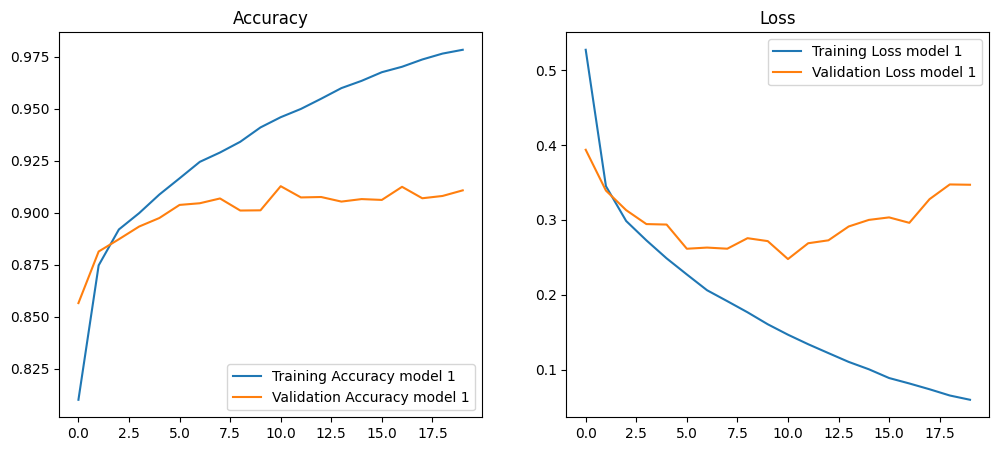

model 2


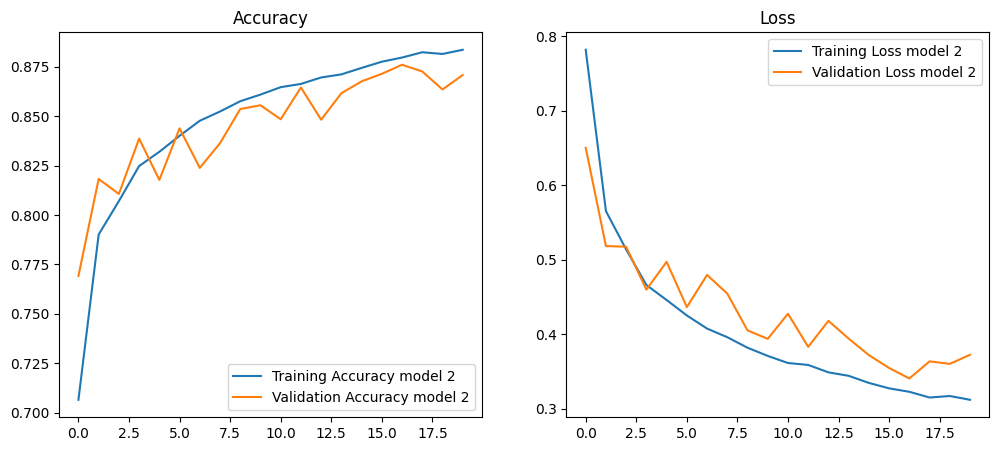

In [18]:

print("model 1")
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']

loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy model 1')
plt.plot(epochs_range, val_acc, label='Validation Accuracy model 1')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss model 1')
plt.plot(epochs_range, val_loss, label='Validation Loss model 1')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()

print("model 2")
acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']

loss = history_2.history['loss']
val_loss = history_2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy model 2')
plt.plot(epochs_range, val_acc, label='Validation Accuracy model 2')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss model 2')
plt.plot(epochs_range, val_loss, label='Validation Loss model 2')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()